# Storm tracking analysis

This notebook shows and example of the storm trackin proccedure and the results, and after computes the storms direction and speed for each tracked storm

In [ ]:
# Packages:
#import netCDF4 as nc
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.patches import Ellipse # draw ellipse on figures
import numpy as np
from pyproj import Transformer # convert lat/lon to projected coordinates

from geographiclib.geodesic import Geodesic # compute storm centroid movement
import geopandas as gpd # read shapefiles
import os
import pandas as pd


In [2]:

# import storm dataset
from functions.storm_dataset import storm_tracking_event, continuos_storm, storm_tracking_features
from functions.storm_motion_grid import (
    build_storm_motion_grid,
    plot_storm_motion_grid_step,
    plot_storm_motion_grid_steps,
)


In [3]:
import importlib
import functions.storm_motion_grid as smg
importlib.reload(smg)

<module 'functions.storm_motion_grid' from '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer/functions/storm_motion_grid.py'>

## Read the datasets

In [4]:

# Set the SST catalog folder path
folder = "/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/RainyDay_Runs/Run_CONUS/Results/Domain_22.0_circle_10000km2/StormCatalog/"
event_list = os.listdir(folder)
event_list = [event for event in event_list if event.endswith('.nc')]
# Load the watershed shapefile
shapefile_path = "/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/RainyDay_Runs/Run_CONUS/Shapes/control_area_circle_22.0.shp"
wsh = gpd.read_file(shapefile_path)
# Load Domain shapefile
transposition_domain = gpd.read_file('/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/RainyDay_Runs/Run_CONUS/Domains/Domain_22.shp')

# Compute the centroid of the original basin
basin_centroid = wsh.geometry.centroid
x_basin_centroid = basin_centroid.x.mean()
y_basin_centroid = basin_centroid.y.mean()



/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_26149/4225006542.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  basin_centroid = wsh.geometry.centroid


### Dictionary for store the storm tracking chacateristics for each event

In [5]:
# Initialize an empty dictionary to store the results
storm_tracking_results = {}
# Iterate over each event in the event_list
event_list.sort()


# Iterate over each event in the event_list
event_list.sort()
for event in event_list:
    # Initialize an empty dictionary for each event
    storm_tracking_results[event] = {}

### See the names of the Storm Catalog

### Apply a storm tracking method as post-processing
Using the functions storm_tracking.py

In [6]:

# Output folder for frames
n_storm = 380 # storm number
name = [s for s in event_list if str(n_storm) in s][0]
ds = xr.open_dataset(os.path.join(folder, name))
event_dict = {}
storm_tracking_event(ds, event_dict)
continuos_storm(event_dict)
storm_tracking_features(event_dict)

#event_dict['lon_array']
#transformer = Transformer.from_crs("EPSG:32633", "EPSG:4326", always_xy=True)
#event_dict['storm_record']['ellipse_lon']


The longest storm has a valid duration of 24 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2004-10-20T03:00:00.000000000 to 2004-10-21T02:00:00.000000000
Selected storm duration 24 hours


{'storm_pcrp': <xarray.Variable (time: 24, latitude: 150, longitude: 150)> Size: 2MB
 array([[[0.1875, 0.3125, ..., 0.125 , 0.125 ],
         [0.1875, 0.1875, ..., 0.125 , 0.125 ],
         ...,
         [0.    , 0.    , ..., 0.    , 0.    ],
         [0.    , 0.    , ..., 0.    , 0.    ]],
 
        [[0.8125, 1.    , ..., 0.125 , 0.    ],
         [0.875 , 0.8125, ..., 0.125 , 0.125 ],
         ...,
         [0.    , 0.    , ..., 0.    , 0.    ],
         [0.    , 0.    , ..., 0.    , 0.    ]],
 
        ...,
 
        [[0.1875, 0.1875, ..., 0.375 , 0.5   ],
         [0.1875, 0.1875, ..., 0.625 , 0.6875],
         ...,
         [0.    , 0.    , ..., 2.3125, 2.8125],
         [0.    , 0.    , ..., 1.5   , 2.    ]],
 
        [[0.1875, 0.3125, ..., 0.375 , 0.625 ],
         [0.3125, 0.1875, ..., 0.625 , 0.8125],
         ...,
         [0.    , 0.    , ..., 1.875 , 2.3125],
         [0.    , 0.    , ..., 1.875 , 2.    ]]],
       shape=(24, 150, 150), dtype=float32)
 Attributes:
     uni

In [7]:
name

'IOWA_Domain.nc_storm_380_20041020.nc'

In [8]:
import cartopy.feature as cfeature
from shapely.affinity import translate
from matplotlib.lines import Line2D
from IPython.display import Image, display
import imageio
import cartopy.crs as ccrs  # Ensure Cartopy is imported

In [9]:
# Get the mask, this is to get the storm centroid
gridmask = ds['gridmask']
# Trim the mask
csum=np.where(np.sum(gridmask,axis=0)==0)
rsum=np.where(np.sum(gridmask,axis=1)==0)
trimmask=np.delete(gridmask,csum,axis=1)
trimmask=np.delete(trimmask,rsum,axis=0)
maskwidth=trimmask.shape[1]
maskheight=trimmask.shape[0]
Storm_ID = 400
# Get storm centroid
spatialres = np.abs(ds.longitude[0] - ds.longitude[1])
y_storm_centroid = float(ds.latitude[ds['ylocation'][Storm_ID - 1]].values) + (maskheight / 2) * spatialres
x_storm_centroid = float(ds.longitude[ds['xlocation'][Storm_ID - 1]].values) + (maskwidth / 2) * spatialres



In [10]:
xmax = transposition_domain.total_bounds[2]
xmin = transposition_domain.total_bounds[0]
ymax = transposition_domain.total_bounds[3]
ymin = transposition_domain.total_bounds[1]
extent = [xmin, xmax, ymin, ymax]

motion_grid = build_storm_motion_grid(
    event_dict,
    cell_size_m=10_000,  # 10 km grid cells
    extent = extent
)

In [11]:
motion_grid = smg.build_storm_motion_grid(
    event_dict,
    cell_size_m=20000,
)

diag = smg.diagnose_storm_motion_grid_alignment(event_dict, motion_grid)
diag

{'cell_size_m': 20000,
 'grid_extent': {'x_min': np.float64(-1276150.7207032442),
  'x_max': np.float64(-776150.7207032442),
  'y_min': np.float64(-571104.0750922168),
  'y_max': np.float64(48895.92490778316)},
 'ellipse_center_extent': {'x_min': np.float64(-1030848.0200977513),
  'x_max': np.float64(-939172.4617595678),
  'y_min': np.float64(-400402.42772952665),
  'y_max': np.float64(-203463.46247585185)},
 'ellipse_axis_summary_m': {'major_min': np.float64(398098.16516750416),
  'major_median': np.float64(484101.45978971105),
  'major_max': np.float64(528339.1430534165),
  'minor_min': np.float64(216367.35639131794),
  'minor_median': np.float64(268346.8712221979),
  'minor_max': np.float64(323276.92058861564)},
 'ellipse_centers_inside_grid': 24,
 'ellipse_centers_total': 24,
 'ellipse_centers_inside_grid_if_xy_swapped': 0,
 'inside_cell_counts': array([284, 286, 284, 326, 293, 281, 254, 205, 234, 316, 254, 260, 270,
        275, 272, 243, 233, 240, 247, 236, 236, 232, 218]),
 'lik

In [12]:
for t in range(len(motion_grid["time"])):
    print(t, motion_grid["inside_ellipse"][t].sum())

0 284
1 286
2 284
3 326
4 293
5 281
6 254
7 205
8 234
9 316
10 254
11 260
12 270
13 275
14 272
15 243
16 233
17 240
18 247
19 236
20 236
21 232
22 218


(<Figure size 1500x500 with 6 Axes>,
 array([[<Axes: title={'center': '2004-10-20T03:00 | direction=38.9 deg, bearing=51.1 deg'}, xlabel='Projected x (m)', ylabel='Projected y (m)'>,
         <Axes: title={'center': '2004-10-20T04:00 | direction=106.1 deg, bearing=343.9 deg'}, xlabel='Projected x (m)', ylabel='Projected y (m)'>,
         <Axes: title={'center': '2004-10-20T05:00 | direction=270.9 deg, bearing=179.1 deg'}, xlabel='Projected x (m)', ylabel='Projected y (m)'>]],
       dtype=object))

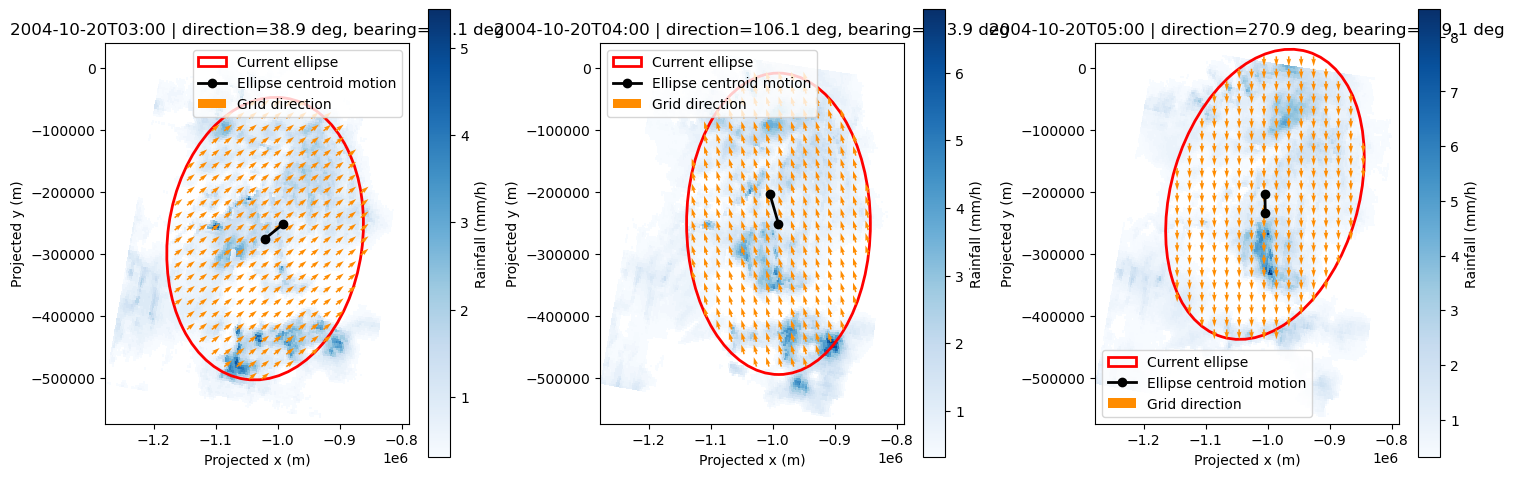

In [13]:
plot_storm_motion_grid_steps(
    event_dict,
    motion_grid,
    time_indices=[0, 1, 2],  # specify the time indices to plot
    rainfall_threshold=0.2,
    vector_stride=1,
    vector_length_fraction=0.8

)

<Axes: title={'center': 'Storm Trajectory, Fitted Ellipses, and All Grid Direction Vectors'}, xlabel='Projected x (m)', ylabel='Projected y (m)'>

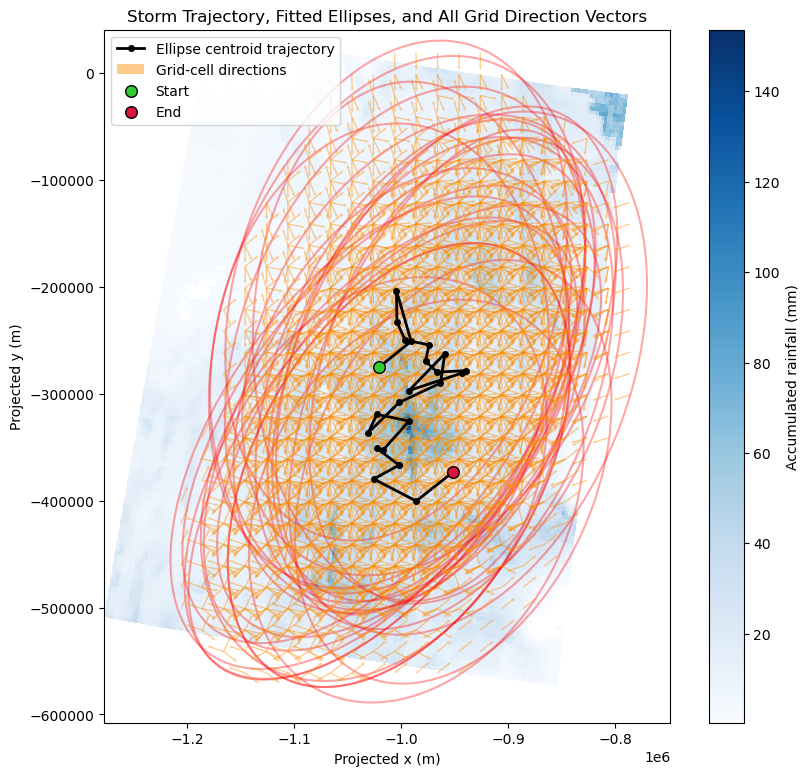

In [14]:
from functions.storm_motion_grid import plot_storm_motion_grid_steps
from functions.storm_motion_grid import plot_storm_motion_grid_all_directions


plot_storm_motion_grid_all_directions(
    event_dict,
    motion_grid,
    vector_stride=1,          # increase if arrows are too dense
    rainfall="accumulated",   # or "max", or None
    direction_alpha=0.45,
    ellipse_alpha=0.35,
    vector_length_fraction=0.8
)

(<Figure size 1500x1000 with 12 Axes>,
 array([[<Axes: title={'center': '2004-10-20T03:00 | direction=38.9 deg, bearing=51.1 deg'}, xlabel='Projected x (m)', ylabel='Projected y (m)'>,
         <Axes: title={'center': '2004-10-20T04:00 | direction=106.1 deg, bearing=343.9 deg'}, xlabel='Projected x (m)', ylabel='Projected y (m)'>,
         <Axes: title={'center': '2004-10-20T05:00 | direction=270.9 deg, bearing=179.1 deg'}, xlabel='Projected x (m)', ylabel='Projected y (m)'>],
        [<Axes: title={'center': '2004-10-20T06:00 | direction=294.5 deg, bearing=155.5 deg'}, xlabel='Projected x (m)', ylabel='Projected y (m)'>,
         <Axes: title={'center': '2004-10-20T07:00 | direction=348.5 deg, bearing=101.5 deg'}, xlabel='Projected x (m)', ylabel='Projected y (m)'>,
         <Axes: title={'center': '2004-10-20T08:00 | direction=258.1 deg, bearing=191.9 deg'}, xlabel='Projected x (m)', ylabel='Projected y (m)'>]],
       dtype=object))

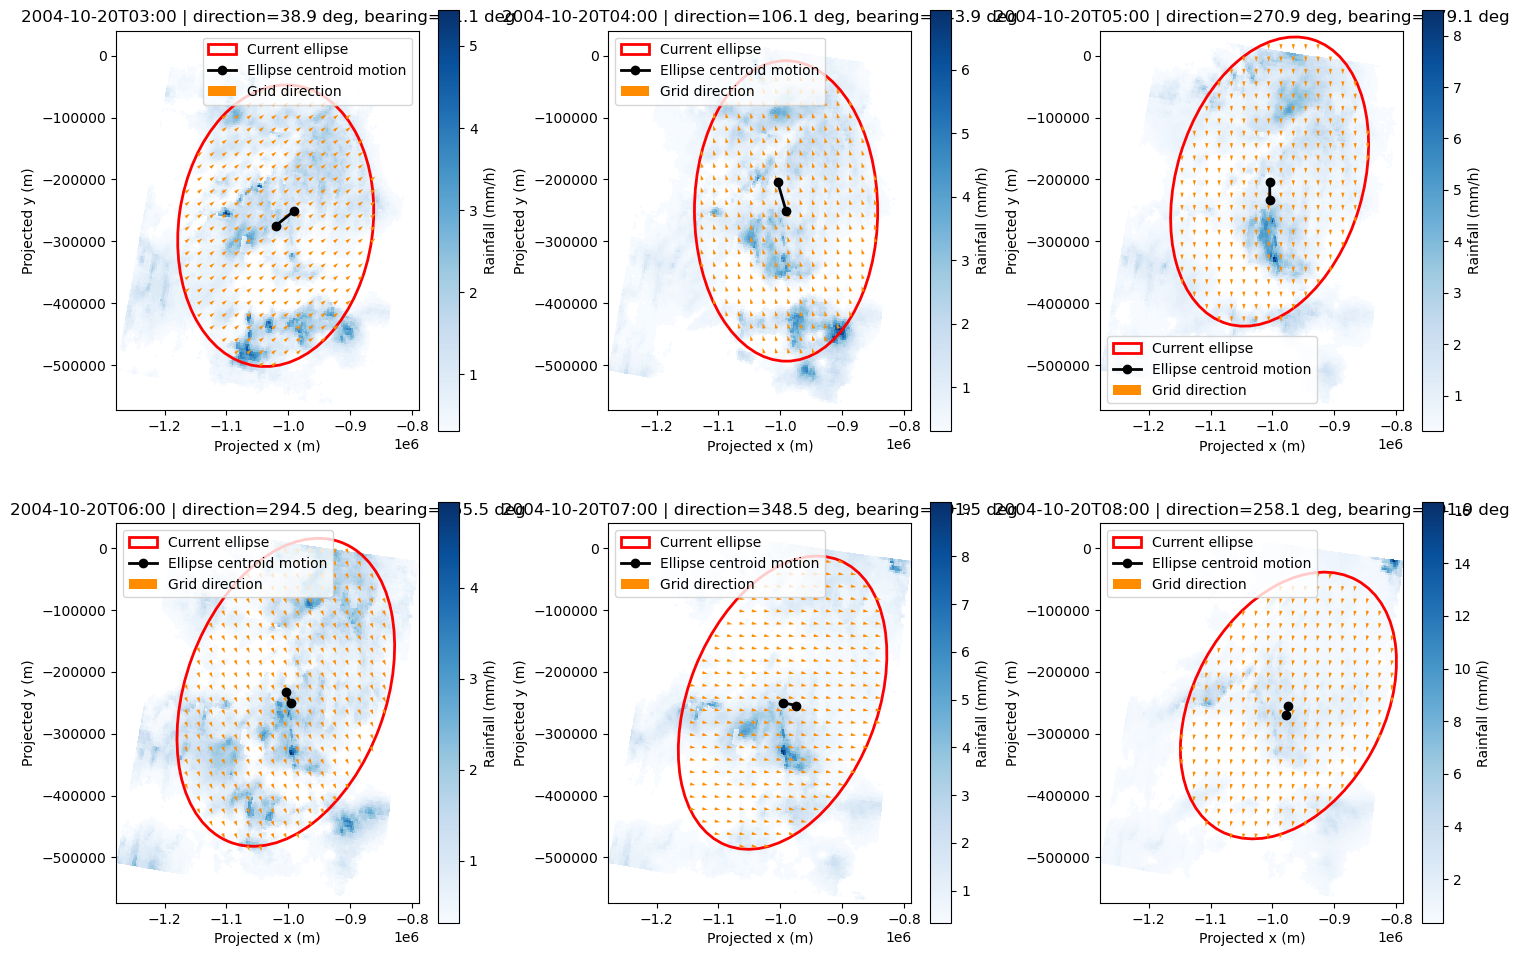

In [15]:
plot_storm_motion_grid_steps(
    event_dict,
    motion_grid,
    time_indices=range(0, min(6, len(motion_grid["time"]))),
    ncols=3,
    vector_stride=1,
)

In [16]:
from functions.storm_motion_grid import (
    build_storm_motion_grid,
    store_grid_directions_over_time,
    plot_storm_motion_grid_all_directions,
)

In [17]:

for storm_event in storm_tracking_results.keys():
    ds = xr.open_dataset(os.path.join(folder, storm_event))
    print(storm_event)
    event_dict = {}
    storm_tracking_event(ds, event_dict, morph_radius=2, high_threshold=0.5)
    continuos_storm(event_dict)
    if event_dict['longest_duration'] >= 5:  # Only analyze storms lasting 6 or more time steps
        storm_tracking_features(event_dict)
    storm_tracking_results[storm_event] = event_dict

IOWA_Domain.nc_storm_100_20100604.nc
The longest storm has a valid duration of 14 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2010-06-04T13:00:00.000000000 to 2010-06-05T02:00:00.000000000
Selected storm duration 14 hours
IOWA_Domain.nc_storm_101_20151116.nc
The longest storm has a valid duration of 8 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2015-11-16T06:00:00.000000000 to 2015-11-16T13:00:00.000000000
Selected storm duration 8 hours
IOWA_Domain.nc_storm_102_20050506.nc
The longest storm has a valid duration of 15 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2005-05-07T06:00:00.000000000 to 2005-05-07T20:00:00.000000000
Selected storm duration 15 hours
IOWA_Domain.nc_storm_103_20221210.nc
The longest storm has a valid duration of 13 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2022-12-11T00:00:00.000000000 to 2022-12-1

In [18]:
storm_tracking_results.keys()

dict_keys(['IOWA_Domain.nc_storm_100_20100604.nc', 'IOWA_Domain.nc_storm_101_20151116.nc', 'IOWA_Domain.nc_storm_102_20050506.nc', 'IOWA_Domain.nc_storm_103_20221210.nc', 'IOWA_Domain.nc_storm_104_20091020.nc', 'IOWA_Domain.nc_storm_105_20110607.nc', 'IOWA_Domain.nc_storm_106_20191212.nc', 'IOWA_Domain.nc_storm_107_20200423.nc', 'IOWA_Domain.nc_storm_108_20100118.nc', 'IOWA_Domain.nc_storm_109_20170203.nc', 'IOWA_Domain.nc_storm_10_20150523.nc', 'IOWA_Domain.nc_storm_110_20141101.nc', 'IOWA_Domain.nc_storm_111_20170220.nc', 'IOWA_Domain.nc_storm_112_20160611.nc', 'IOWA_Domain.nc_storm_113_20100908.nc', 'IOWA_Domain.nc_storm_114_20070922.nc', 'IOWA_Domain.nc_storm_115_20121118.nc', 'IOWA_Domain.nc_storm_116_20190920.nc', 'IOWA_Domain.nc_storm_117_20211018.nc', 'IOWA_Domain.nc_storm_118_20110307.nc', 'IOWA_Domain.nc_storm_119_20090224.nc', 'IOWA_Domain.nc_storm_11_20190911.nc', 'IOWA_Domain.nc_storm_120_20020501.nc', 'IOWA_Domain.nc_storm_121_20080110.nc', 'IOWA_Domain.nc_storm_122_20100

In [19]:
cell_size_m = 20_000
storm_motion_results = {}

storm_names = list(storm_tracking_results.keys())  # or select a subset

for storm_name in storm_names:
    event_dict = storm_tracking_results[storm_name]

    # Skip storms that do not have enough tracked time steps
    if "storm_record" not in event_dict or len(event_dict["storm_record"]) < 2:
        print(f"Skipping {storm_name}: missing storm_record or too short")
        continue

    motion_grid = build_storm_motion_grid(
        event_dict,
        cell_size_m=cell_size_m,
    )

    grid_directions_all = store_grid_directions_over_time(
        motion_grid,
        mode="all",
    )

    storm_motion_results[storm_name] = {
        "motion_grid": motion_grid,
        "directions_all": grid_directions_all,
    }

In [20]:
from functions.storm_motion_grid import (
    calculate_direction_probability_field,
    plot_direction_probability_field,
)

In [34]:
prob_field = calculate_direction_probability_field(
    storm_motion_results,
    angle_bin_size=90,     # 0-45, 45-90, ..., 315-360
    start_angle=-45,        # 0 degrees corresponds to east if use_bearing=False, north if use_bearing=True
    use_bearing=False,     # False: 0=east, True: 0=north
)

In [35]:
prob_field.keys()

dict_keys(['angle_ranges', 'angle_labels', 'start_angle', 'angle_bin_size', 'use_bearing', 'direction_type', 'probability', 'bin_counts', 'total_counts', 'x_edges', 'y_edges', 'x_centers', 'y_centers', 'x_grid', 'y_grid', 'cell_size_m'])

<Axes: title={'center': 'Direction Probability: -45-45 deg'}, xlabel='Projected x (m)', ylabel='Projected y (m)'>

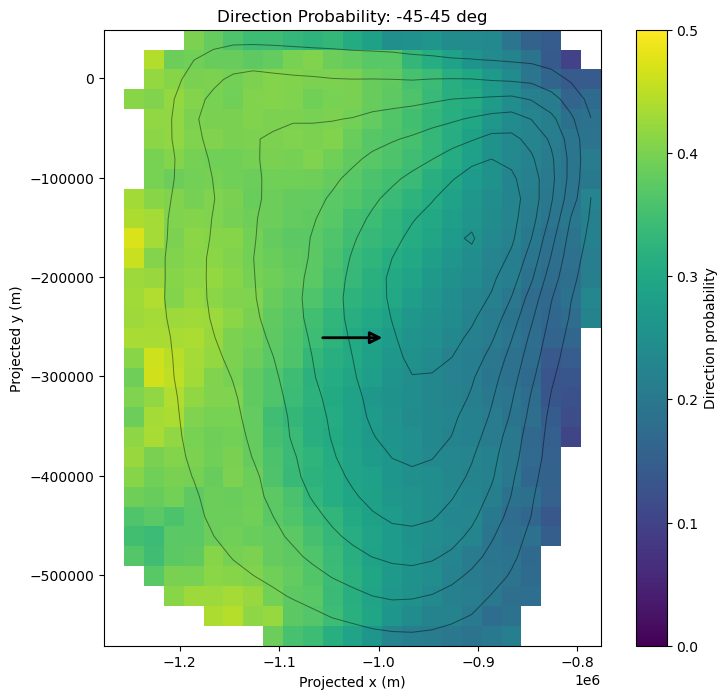

In [36]:
plot_direction_probability_field(
    prob_field,
    bin_index=0,           # first bin: 0-45 deg
    show_counts=True,
    vmin=0, vmax=0.5,
    count_threshold=100,      # only show counts if there are at least this many samples
)

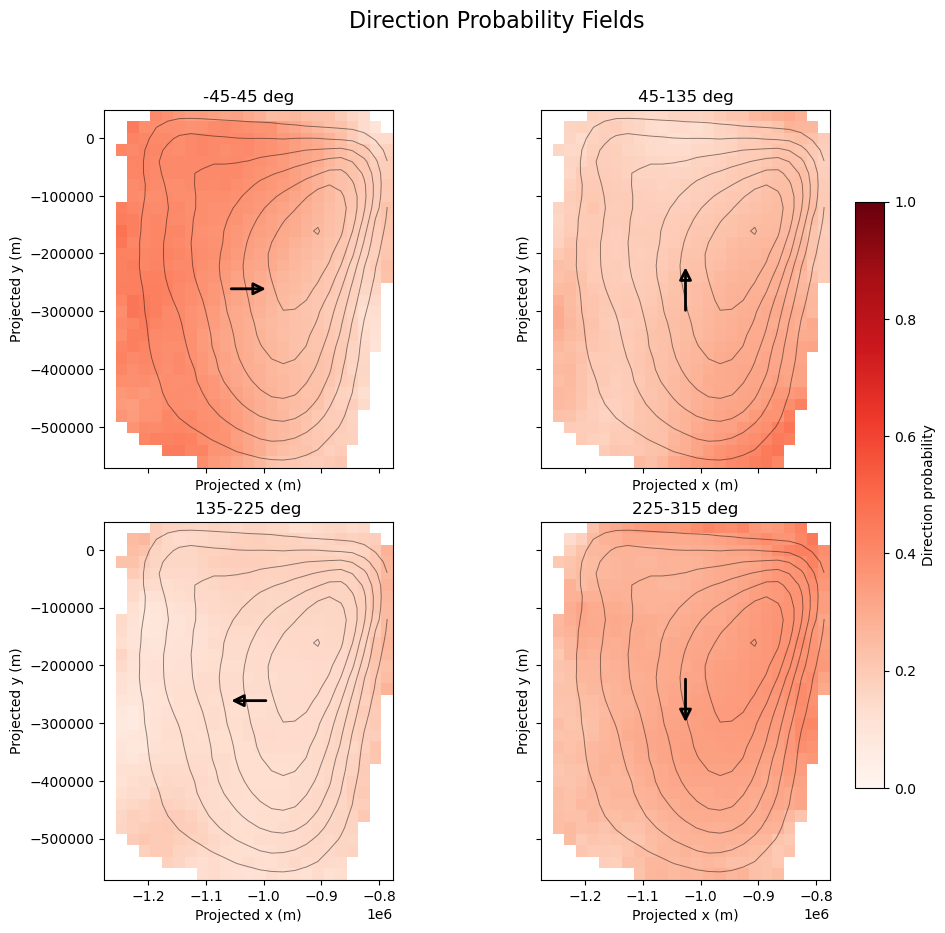

In [44]:
import matplotlib.pyplot as plt

bin_indices = [0, 1, 2, 3]  # choose the 4 direction bins you want

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10),
    sharex=True,
    sharey=True,
)
plt.subplots_adjust(wspace=0.01, hspace=0.15)
vmin = 0
vmax = 1
probability_range = None  # or e.g. (0.2, 1.0)

mappable = None

for ax, bin_index in zip(axes.ravel(), bin_indices):
    plot_direction_probability_field(
        prob_field,
        bin_index=bin_index,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        probability_range=probability_range,
        show_counts=True,
        count_threshold=100,
        cmap="Reds"
    )

    ax.set_title(prob_field["angle_labels"][bin_index])

    # Get the pcolormesh object created by the function
    mappable = ax.collections[0]

# Remove individual colorbars created by the function
for ax in axes.ravel():
    if len(fig.axes) > 4:
        fig.axes[-1].remove()

# Add one shared colorbar
cbar = fig.colorbar(
    mappable,
    ax=axes.ravel().tolist(),
    orientation="vertical",
    fraction=0.035,
    pad=0.03,
)
cbar.set_label("Direction probability")

fig.suptitle("Direction Probability Fields", fontsize=16)

plt.show()

In [33]:
prob_sum = prob_sum = np.nansum(prob_field["probability"], axis=0)

In [45]:
prob_field["total_counts"]

array([[   4,   11,   14,   23,   31,   49,   74,   90,  111,  147,  187,
         241,  282,  317,  349,  359,  336,  293,  232,  173,  104,   40,
          16,    5,    1],
       [  19,   23,   37,   52,   70,  107,  142,  176,  228,  283,  341,
         418,  472,  550,  588,  590,  550,  471,  387,  265,  192,   87,
          25,    7,    1],
       [  33,   56,   78,  112,  152,  188,  233,  284,  350,  423,  502,
         610,  708,  799,  852,  837,  780,  669,  553,  383,  265,  140,
          49,   11,    3],
       [  52,   88,  130,  178,  216,  269,  340,  395,  463,  571,  692,
         820,  921, 1000, 1067, 1087, 1033,  900,  722,  540,  362,  203,
          77,   19,    7],
       [  74,  112,  170,  222,  257,  330,  414,  501,  585,  728,  875,
         988, 1112, 1208, 1276, 1300, 1252, 1129,  933,  693,  468,  250,
          96,   32,    7],
       [  75,  138,  188,  239,  315,  397,  485,  584,  713,  862,  997,
        1144, 1266, 1418, 1497, 1521, 1458, 1325, 1

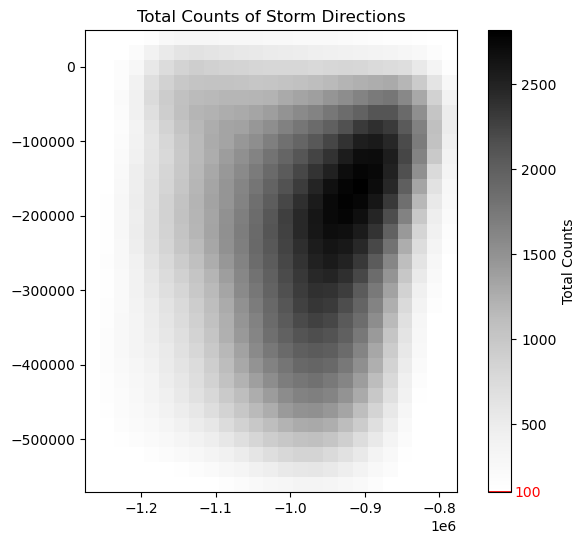

In [51]:
# plot of the total counts
count_threshold = 100

prob_counts = np.where(
    prob_field["total_counts"] >= count_threshold,
    prob_field["total_counts"],
    np.nan,
)

fig, ax = plt.subplots(figsize=(8, 6))

mesh = ax.pcolormesh(
    prob_field["x_edges"],
    prob_field["y_edges"],
    prob_counts,
    cmap="Greys",
    shading="auto",
)

cbar = fig.colorbar(mesh, ax=ax, label="Total Counts")
cbar.ax.axhline(count_threshold, color="red", linewidth=2)
cbar.ax.text(
    1.15,
    count_threshold,
    f"{count_threshold}",
    color="red",
    va="center",
    ha="left",
    transform=cbar.ax.get_yaxis_transform(),
)

ax.set_title("Total Counts of Storm Directions")
ax.set_aspect("equal")
plt.show()

## direction of centroids trajectory

## Trajectory event visualization

### The code generates a Gif for a specific storm event showing its centroid trajectories 

The longest storm has a valid duration of 23 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2016-09-15T10:00:00.000000000 to 2016-09-16T08:00:00.000000000
Selected storm duration 23 hours


/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_9326/2064153284.py:81: UserWarning: Legend does not support handles for GeoQuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_9326/2064153284.py:81: UserWarning: Legend does not support handles for GeoQuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_9326/2064153284.py:81: UserWarning: Legend does not support handles for GeoQuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_9326/2064153284.py:81: UserWarning: Legend does not support handles for GeoQuadMesh instances.


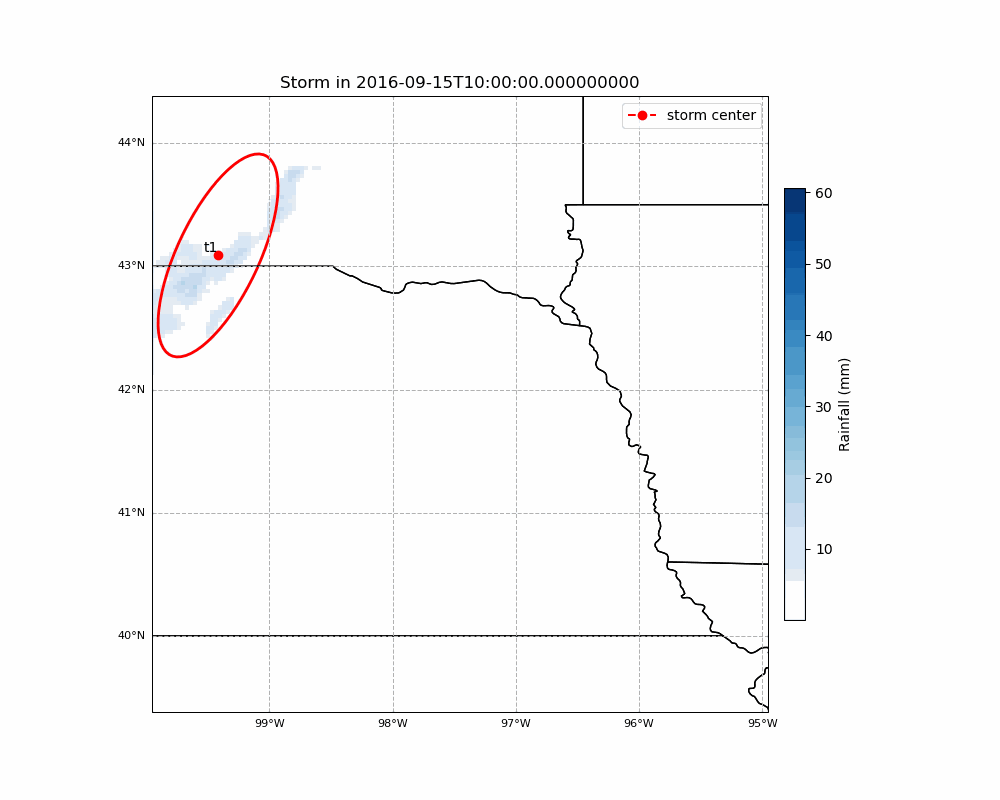

In [26]:
# Output folder for frames

n_storm = 380 # storm number
name = [s for s in event_list if str(n_storm) in s][0] # find the storm name
# Load the dataset
ds = xr.open_dataset(os.path.join(folder, name))

##Run of storm tracking for specif event
event_dict = {}
storm_tracking_event(ds, event_dict, morph_radius=2, high_threshold=0.5)
continuos_storm(event_dict)
storm_tracking_features(event_dict)

#folder for storing gif images
output_folder = "frames" 
os.makedirs(output_folder, exist_ok=True)
frame_file = []

t_list = [f't{i}' for i in range(1, event_dict['selected_storm'].shape[0])] # time list for plotting
# Get the maximum and minimum values for the colorbar
cb_max = ds['rain'].values.max()
cb_min = 0.1
start_time_index = 0  # starting time index for the event
end_time_index = event_dict['selected_storm'].shape[0]  # ending time index for the event
end_time_index = min(end_time_index, 12)  # limit to the first 10 time steps for plotting
## Generation of each time step plot for the event
for time_index in range(start_time_index,end_time_index):
  
    # get current precipitation array
    curr_prcp_array = event_dict['selected_storm'][time_index]
    
    # Create a plot
    
    fig, ax = plt.subplots( figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

    # Plot the projected precipitation data
    rain = ax.pcolormesh(event_dict['lon_array'], event_dict['lat_array'], np.ma.masked_where(curr_prcp_array < 0.1, curr_prcp_array),
                   cmap='Blues', vmax=cb_max, vmin=cb_min, label='Rainfall (mm/h)')
    plt.colorbar(rain, ax=ax, label='Rainfall (mm)', orientation='vertical', shrink=0.7, pad=0.02)
    
    ### Plot the storm centroid
    
    plt.plot(event_dict['storm_lon_cent'][start_time_index:time_index+1], 
             event_dict['storm_lat_cent'][start_time_index:time_index+1], 'ro--', 
               label = 'storm center')
    for lon, lat, label in zip(event_dict['storm_lon_cent'][start_time_index:time_index+1], 
                           event_dict['storm_lat_cent'][start_time_index:time_index+1], 
                           t_list[start_time_index:time_index+1]):
        plt.text(lon, lat, label, fontsize=10, ha='right', va='bottom')
    # plt.scatter(storm_lon_cent, storm_lat_cent)
    # scatter = ax.scatter(x_coords, y_coords, c=precipitation_data, cmap='viridis')
    # plt.colorbar(scatter, ax=ax, label='Precipitation')
    #basin_transposed.plot(ax=ax,  edgecolor='green', facecolor='none', label='Basin')
    
    # Plot the fitted ellipse
    ellipse_artist = Ellipse(
        xy=(event_dict['storm_lon_cent'][time_index], event_dict['storm_lat_cent'][time_index]),
        width=event_dict['storm_record']['matplotlib_width(m)'][time_index]/111000, # the length of horizontal axis
        height=event_dict['storm_record']['matplotlib_height(m)'][time_index]/111000, # the length of vertical axis
        angle=event_dict['storm_record']['ellipse_angle (degree)'][time_index],
        edgecolor='red',
        fill=False,
        linewidth=2,
    )
    ax.add_artist(ellipse_artist)
    # Add U.S. state boundaries
    ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=1)
    # Add grid with labeled coordinates
    gl1 = ax.gridlines(draw_labels=True, linestyle='--')
    gl1.top_labels = False
    gl1.right_labels = False
    font_size = 8  # Set the desired font size
    gl1.xlabel_style = {'size': font_size}  # Set font size for x-axis labels
    gl1.ylabel_style = {'size': font_size}  # Set font size for y-axis labels

    # Set the axis labels
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    title = event_dict['selected_storm_time_steps'].values[time_index]
    ax.set_title(f'Storm in {title}')
    plt.legend()
    # Show the plot
    # Save the frame
    frame_path = os.path.join(output_folder, f"frame_{time_index}.png")
   
    plt.savefig(frame_path)
    plt.close(fig)
    frame_file.append(frame_path)

# Create GIF
gif_path = f"/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/StormTracking_OK/storm_animation_{n_storm}.gif"
imageio.mimsave(gif_path, [imageio.imread(f) for f in frame_file], fps=2)

# Display GIF in IPython notebook
display(Image(filename=gif_path))


In [10]:
from functions.storm_motion_grid import (
    build_storm_motion_grid,
    plot_storm_motion_grid_step,
    plot_storm_motion_grid_steps,
)

ModuleNotFoundError: No module named 'functions.storm_motion_grid'

In [ ]:
from functions.storm_motion_grid import (
    build_storm_motion_grid,
    plot_storm_motion_grid_step,
    plot_storm_motion_grid_steps,
)

event_dict = storm_tracking_results[storm_name]  # or your current storm dict

motion_grid = build_storm_motion_grid(
    event_dict,
    cell_size_m=10_000,  # meters
)

motion_grid["records"].head()

The longest storm has a valid duration of 0 hours
The selected duration is shorted than 0.1 of 24 hours, skip this event
Selected storm starts from 2003-07-16T13:00:00.000000000 to 2003-07-17T12:00:00.000000000
Selected storm duration 24 hours


/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_74235/2456643314.py:58: UserWarning: Legend does not support handles for GeoQuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_74235/2456643314.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_74235/2456643314.py:58: UserWarning: Legend does not support handles for GeoQuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_74235/2456643314.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whos

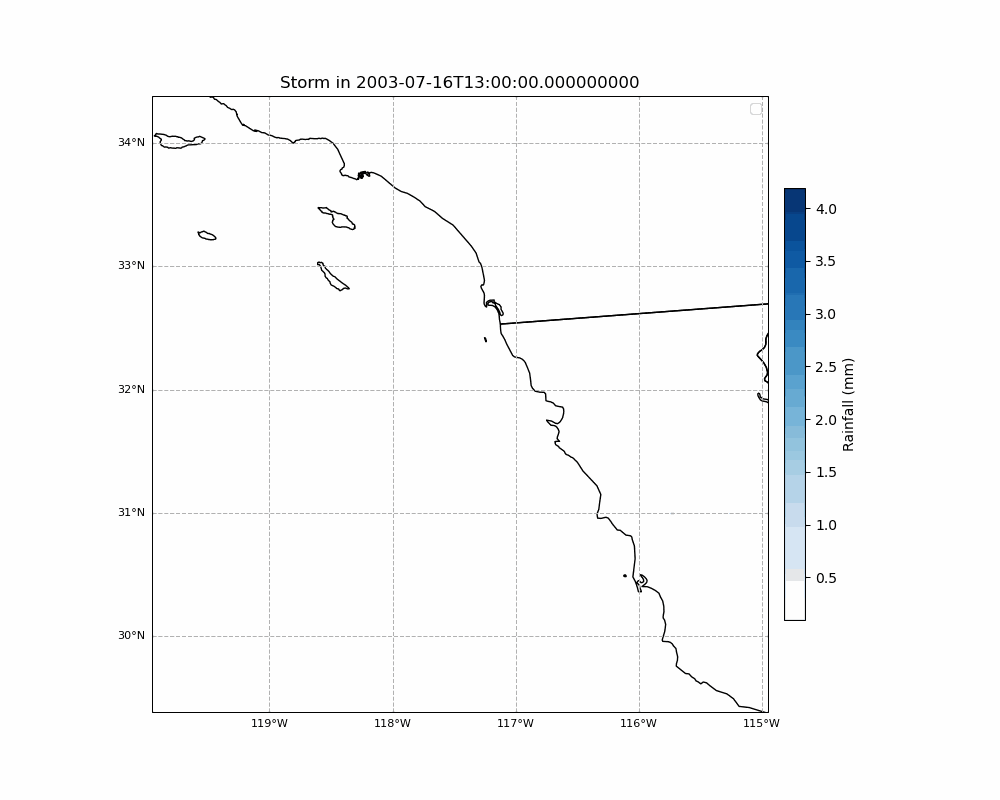

In [23]:
# Output folder for frames

n_storm = 103 # storm number
name = [s for s in event_list if str(n_storm) in s][0] # find the storm name
# Load the dataset
ds = xr.open_dataset(os.path.join(folder, name))

##Run of storm tracking for specif event
event_dict = {}
storm_tracking_event(ds, event_dict, morph_radius=2, high_threshold=0.5)
continuos_storm(event_dict)
storm_tracking_features(event_dict)

#folder for storing gif images
output_folder = "frames" 
os.makedirs(output_folder, exist_ok=True)
frame_file = []

t_list = [f't{i}' for i in range(1, event_dict['selected_storm'].shape[0])] # time list for plotting
# Get the maximum and minimum values for the colorbar
cb_max = event_dict['selected_storm'].max()
cb_min = 0.1
start_time_index = 6  # starting time index for the event
end_time_index = 16   # ending time index for the event
## Generation of each time step plot for the event
for time_index in range(0, event_dict['selected_storm'].shape[0]):
  
    # get current precipitation array
    curr_prcp_array = event_dict['selected_storm'][time_index]
    
    # Create a plot
    
    fig, ax = plt.subplots( figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

    # Plot the projected precipitation data
    rain = ax.pcolormesh(event_dict['lon_array'], event_dict['lat_array'], np.ma.masked_where(curr_prcp_array < 0.1, curr_prcp_array),
                   cmap='Blues', vmax=cb_max, vmin=cb_min, label='Rainfall (mm/h)')
    plt.colorbar(rain, ax=ax, label='Rainfall (mm)', orientation='vertical', shrink=0.7, pad=0.02)
    
    ### Plot the storm centroid
    
    
    # Add U.S. state boundaries
    ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=1)
    # Add grid with labeled coordinates
    gl1 = ax.gridlines(draw_labels=True, linestyle='--')
    gl1.top_labels = False
    gl1.right_labels = False
    font_size = 8  # Set the desired font size
    gl1.xlabel_style = {'size': font_size}  # Set font size for x-axis labels
    gl1.ylabel_style = {'size': font_size}  # Set font size for y-axis labels

    # Set the axis labels
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    title = event_dict['selected_storm_time_steps'].values[time_index]
    ax.set_title(f'Storm in {title}')
    plt.legend()
    # Show the plot
    # Save the frame
    frame_path = os.path.join(output_folder, f"frame_{time_index}.png")
   
    plt.savefig(frame_path)
    plt.close(fig)
    frame_file.append(frame_path)

# Create GIF
gif_path = f"/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/StormTracking_OK/storm_animation_{n_storm}_field.gif"
imageio.mimsave(gif_path, [imageio.imread(f) for f in frame_file], fps=3)

# Display GIF in IPython notebook
display(Image(filename=gif_path))

/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_62147/3884627246.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  imageio.mimsave(gif_path, [imageio.imread(f) for f in frame_file], fps=5)


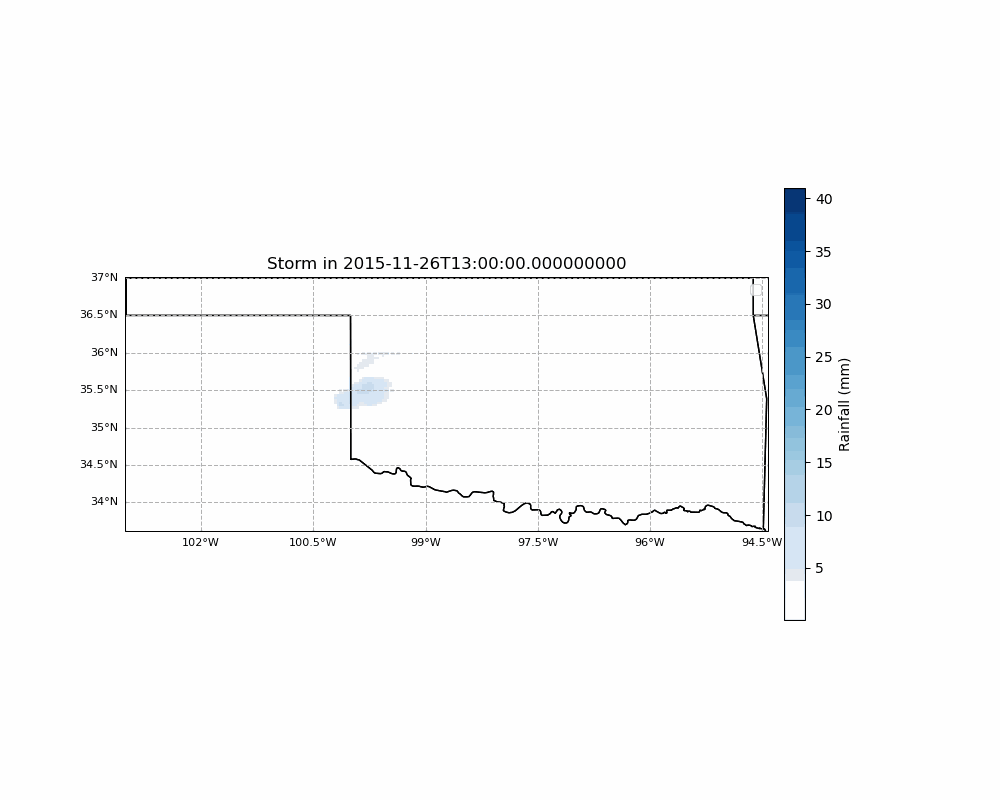

In [19]:
# Create GIF
gif_path = f"/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/StormTracking_OK/storm_animation_{n_storm}_field.gif"
imageio.mimsave(gif_path, [imageio.imread(f) for f in frame_file], fps=5)

# Display GIF in IPython notebook
display(Image(filename=gif_path))

In [8]:
# Output folder for frames

n_storm = 103 # storm number
name = [s for s in event_list if str(n_storm) in s][0] # find the storm name
# Load the dataset
ds = xr.open_dataset(os.path.join(folder, name))


#folder for storing gif images
output_folder = "frames" 
os.makedirs(output_folder, exist_ok=True)
frame_file = []

t_list = [f't{i}' for i in range(1, event_dict['selected_storm'].shape[0])] # time list for plotting
# Get the maximum and minimum values for the colorbar
cb_max = event_dict['selected_storm'].max()
cb_min = 0.1
start_time_index = 6  # starting time index for the event
end_time_index = 16   # ending time index for the event
## Generation of each time step plot for the event
for time_index in range(0, event_dict['selected_storm'].shape[0]):
  
    # get current precipitation array
    curr_prcp_array = event_dict['selected_storm'][time_index]
    
    # Create a plot
    
    fig, ax = plt.subplots( figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

    # Plot the projected precipitation data
    rain = ax.pcolormesh(event_dict['lon_array'], event_dict['lat_array'], np.ma.masked_where(curr_prcp_array < 0.1, curr_prcp_array),
                   cmap='Blues', vmax=cb_max, vmin=cb_min, label='Rainfall (mm/h)')
    plt.colorbar(rain, ax=ax, label='Rainfall (mm)', orientation='vertical', shrink=0.7, pad=0.02)
    
    ### Plot the storm centroid
    
    
    # Add U.S. state boundaries
    ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=1)
    # Add grid with labeled coordinates
    gl1 = ax.gridlines(draw_labels=True, linestyle='--')
    gl1.top_labels = False
    gl1.right_labels = False
    font_size = 8  # Set the desired font size
    gl1.xlabel_style = {'size': font_size}  # Set font size for x-axis labels
    gl1.ylabel_style = {'size': font_size}  # Set font size for y-axis labels

    # Set the axis labels
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    title = event_dict['selected_storm_time_steps'].values[time_index]
    ax.set_title(f'Storm in {title}')
    plt.legend()
    # Show the plot
    # Save the frame
    frame_path = os.path.join(output_folder, f"frame_{time_index}.png")
   
    plt.savefig(frame_path)
    plt.close(fig)
    frame_file.append(frame_path)

# Create GIF
gif_path = f"/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/StormTracking_OK/storm_animation_{n_storm}_field.gif"
imageio.mimsave(gif_path, [imageio.imread(f) for f in frame_file], fps=3)

# Display GIF in IPython notebook
display(Image(filename=gif_path))

NameError: name 'ccrs' is not defined

In [ ]:
import imageio
import cartopy.crs as ccrs
# Create output folder for frames
output_folder = "frames_animation"
os.makedirs(output_folder, exist_ok=True)
frame_file = []
n_storm = 103 # storm number
name = [s for s in event_list if str(n_storm) in s][0] # find the storm name
# Load the dataset
ds = xr.open_dataset(os.path.join(folder, name))
# Get the maximum and minimum values for the colorbar
cb_max = ds['rain'].values.max()
cb_min = 0.1

# Generate frames for each time step
for time_index in range(ds.dims['time']):
    

    # Create output folder for frames
    output_folder = "frames_animation"
    os.makedirs(output_folder, exist_ok=True)
    frame_file = []

    # Get the maximum and minimum values for the colorbar
    cb_max = ds['rain'].values.max()
    cb_min = 0.1

    # Generate frames for each time step
    for time_index in range(ds.dims['time']):
        fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
        
        # Plot the masked precipitation data
        rain_data = ds['rain'].isel(time=time_index).values
        rain = ax.pcolormesh(ds['longitude'].values, ds['latitude'].values, 
                             np.ma.masked_where(rain_data < cb_min, rain_data),
                             cmap='Blues', vmax=cb_max, vmin=cb_min)
        plt.colorbar(rain, ax=ax, label='Rainfall (mm/h)', orientation='vertical', shrink=0.7)
        
        # Add features
        ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5)
        gl = ax.gridlines(draw_labels=True, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        title = ds['time'].values[time_index]
        ax.set_title(f'Rainfall at {title}')
        
        # Save frame
        frame_path = os.path.join(output_folder, f"frame_{time_index:02d}.png")
        plt.savefig(frame_path, dpi=100, bbox_inches='tight')
        plt.close(fig)
        frame_file.append(frame_path)

    # Create GIF
    gif_path = "rainfall_animation.gif"
    imageio.mimsave(gif_path, [imageio.imread(f) for f in frame_file], fps=2)
    display(Image(filename=gif_path))
    
    # Plot the masked precipitation data
    rain_data = ds['rain'].isel(time=time_index).values
    rain = ax.pcolormesh(ds['longitude'].values, ds['latitude'].values, 
                         np.ma.masked_where(rain_data < cb_min, rain_data),
                         cmap='Blues', vmax=cb_max, vmin=cb_min)
    plt.colorbar(rain, ax=ax, label='Rainfall (mm/h)', orientation='vertical', shrink=0.7)
    
    # Add features
    ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5)
    gl = ax.gridlines(draw_labels=True, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    title = ds['time'].values[time_index]
    ax.set_title(f'Rainfall at {title}')
    
    # Save frame
    frame_path = os.path.join(output_folder, f"frame_{time_index:02d}.png")
    plt.savefig(frame_path, dpi=100, bbox_inches='tight')
    plt.close(fig)
    frame_file.append(frame_path)

# Create GIF
gif_path = "rainfall_animation.gif"
imageio.mimsave(gif_path, [imageio.imread(f) for f in frame_file], fps=2)
display(Image(filename=gif_path))

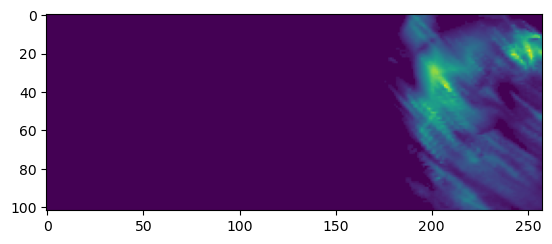

In [12]:
plt.imshow(event_dict['selected_storm'][8])

## Run storm track for the entire storm catalog

In [10]:
for storm_event in storm_tracking_results.keys():
    ds = xr.open_dataset(os.path.join(folder, storm_event))
    print(storm_event)
    event_dict = {}
    storm_tracking_event(ds, event_dict)
    continuos_storm(event_dict)
    storm_tracking_features(event_dict)
    storm_tracking_results[storm_event] = event_dict

Oklahoma_Watershed_CIMARRON.nc_storm_100_20191007.nc
The longest storm has a valid duration of 23 hours
The selected duration is longer than 0.1 of 192 hours
Selected storm starts from 2019-10-10T12:00:00.000000000 to 2019-10-11T13:00:00.000000000
Selected storm duration 26 hours
Oklahoma_Watershed_CIMARRON.nc_storm_101_20201121.nc
The longest storm has a valid duration of 26 hours
The selected duration is longer than 0.1 of 192 hours
Selected storm starts from 2020-11-28T10:00:00.000000000 to 2020-11-29T11:00:00.000000000
Selected storm duration 26 hours
Oklahoma_Watershed_CIMARRON.nc_storm_102_20211214.nc
The longest storm has a valid duration of 27 hours
The selected duration is longer than 0.1 of 192 hours
Selected storm starts from 2021-12-17T10:00:00.000000000 to 2021-12-18T12:00:00.000000000
Selected storm duration 27 hours
Oklahoma_Watershed_CIMARRON.nc_storm_103_20211226.nc
The longest storm has a valid duration of 17 hours
The selected duration is shorted than 0.1 of 192 hour

/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Paper_Notebooks/Pilot_Study/Pilot_Study/functions/storm_catalog_functions.py:92: RuntimeWarning: invalid value encountered in divide
  x_avg = np.sum((lon_array * curr_prcp_array) / sum_ivt)
/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Paper_Notebooks/Pilot_Study/Pilot_Study/functions/storm_catalog_functions.py:93: RuntimeWarning: invalid value encountered in divide
  y_avg = np.sum((lat_array * curr_prcp_array) / sum_ivt)


IndexError: index -1 is out of bounds for axis 0 with size 0

## Estimates the storm speed and direction for each storm catalog

In [9]:
# import the functions of storm_direction.py file
from functions.storm_direction import mean_direction, mean_velocity, mean_direction_ln, mean_precipitation_within_ellipse, get_max_accumulated_value, compute_line_length

In [36]:
# list for storing the results
storm_mean_velocity = []
storm_mean_direction_vector = []
storm_mean_direction_lm = []
position=[]

for storm_event in storm_tracking_results.keys():
    storm = storm_tracking_results[storm_event]
    x, y = storm['storm_prj_lon_cent_list'], storm['storm_prj_lat_cent_list']
    
    # Compute the mean velocity and direction
    v = mean_velocity(x, y)
    d = mean_direction(x, y)
    lm = mean_direction_ln(x, y)[0]
    # Append the results to the lists
    storm_mean_velocity.append(v)
    storm_mean_direction_vector.append(d)
    storm_mean_direction_lm.append(lm)
    position.append(storm_event[-20:-12]) # storm ID
    # Saving the results for each storm
    storm_tracking_results[storm_event]['mean_velocity'] = v
    storm_tracking_results[storm_event]['mean_direction'] = d
    storm_tracking_results[storm_event]['mean_direction_ln'] = lm


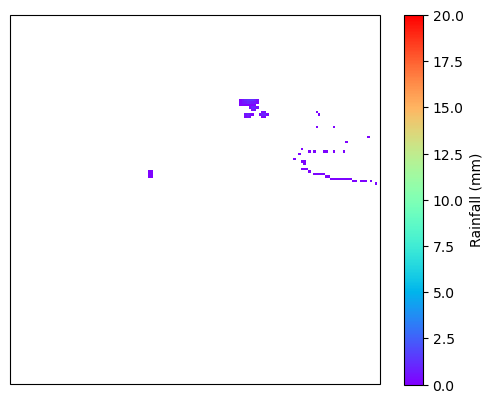

In [24]:
n_storm = 184 # storm number
name = [s for s in event_list if str(n_storm) in s][0] # find the storm name
pr = storm_tracking_results[name]
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
# get current precipitation array
curr_prcp_array = pr['selected_storm'][0]
# Plot the projected precipitation data
rain = plt.pcolormesh(pr['lon_array'], pr['lat_array'], np.ma.masked_where(curr_prcp_array < 0.01, curr_prcp_array),
                cmap='rainbow', vmax=20, vmin=0, label='Rainfall (mm/h)')
plt.colorbar(rain, ax=ax, label='Rainfall (mm)', orientation='vertical')

In [25]:
print(mean_precipitation_within_ellipse(pr))


[-836.8567  -836.85675 -836.85675 -836.85675 -836.85675 -836.85675
 -836.85675 -836.85675 -836.8567  -836.85675 -836.85675 -836.8529
 -836.85675 -836.85675 -836.85675 -836.85675 -836.85675 -836.85675
 -836.85675 -836.85675 -836.85675 -836.85675 -836.85675 -836.85675]


In [26]:
pr['storm_record']

,duration(hour),time,year,month,avg_prcp(mm/h),max_prcp(mm/h),cent_lon(degree),cent_lat(degree),cen_prj_lon(m),cen_prj_lat(m),...,distance(km),major_axis_length(m),minor_axis_length(m),ellipse_angle (degree),ellipse_cent_prj_lon(m),ellipse_cent_prj_lat(m),ellipse_cent_lon,ellipse_cent_lat,matplotlib_width(m),matplotlib_height(m)
0,24,2003-12-08 13:00:00,2003,12,-700711.037985,1.1875,-77.999532,48.211731,1.604888e+06,580779.673411,...,0.000000,889662.5625,467591.125,23.61916,1765889.125,327159.125,-76.891005,45.639964,467591.125,889662.5625
1,24,2003-12-08 14:00:00,2003,12,-748410.600512,1.1875,-77.999533,48.211731,1.604888e+06,580779.712550,...,0.000087,889662.5625,467591.125,23.61916,1765889.125,327159.125,-76.891005,45.639964,467591.125,889662.5625
2,24,2003-12-08 15:00:00,2003,12,-748410.600512,1.1875,-77.999533,48.211731,1.604888e+06,580779.712550,...,0.000000,889662.5625,467591.125,23.61916,1765889.125,327159.125,-76.891005,45.639964,467591.125,889662.5625
3,24,2003-12-08 16:00:00,2003,12,-748410.600512,1.1875,-77.999533,48.211731,1.604888e+06,580779.712550,...,0.000000,889662.5625,467591.125,23.61916,1765889.125,327159.125,-76.891005,45.639964,467591.125,889662.5625
4,24,2003-12-08 17:00:00,2003,12,-757020.980900,1.1875,-77.999533,48.211731,1.604888e+06,580779.719148,...,0.000014,889662.5625,467591.125,23.61916,1765889.125,327159.125,-76.891005,45.639964,467591.125,889662.5625
5,24,2003-12-08 18:00:00,2003,12,-757091.315941,1.1875,-77.999533,48.211731,1.604888e+06,580779.715669,...,0.000007,889662.5625,467591.125,23.61916,1765889.125,327159.125,-76.891005,45.639964,467591.125,889662.5625
6,24,2003-12-08 19:00:00,2003,12,-740297.159616,1.1875,-77.999533,48.211731,1.604888e+06,580779.705503,...,0.000022,889662.5625,467591.125,23.61916,1765889.125,327159.125,-76.891005,45.639964,467591.125,889662.5625
7,24,2003-12-08 20:00:00,2003,12,-757091.315941,1.1875,-77.999533,48.211731,1.604888e+06,580779.715669,...,0.000022,889662.5625,467591.125,23.61916,1765889.125,327159.125,-76.891005,45.639964,467591.125,889662.5625
8,24,2003-12-08 21:00:00,2003,12,-693602.434496,1.1875,-77.999532,48.211731,1.604888e+06,580779.663462,...,0.000117,889662.5625,467591.125,23.61916,1765889.125,327159.125,-76.891005,45.639964,467591.125,889662.5625
9,24,2003-12-08 22:00:00,2003,12,-740297.159616,1.1875,-77.999533,48.211731,1.604888e+06,580779.705503,...,0.000095,889662.5625,467591.125,23.61916,1765889.125,327159.125,-76.891005,45.639964,467591.125,889662.5625


In [65]:
pr['selected_storm']

array([[[-9999., -9999., -9999., ...,     0.,     0.,     0.],
        [-9999., -9999., -9999., ...,     0.,     0.,     0.],
        [-9999., -9999., -9999., ...,     0.,     0.,     0.],
        ...,
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.]],

       [[-9999., -9999., -9999., ...,     0.,     0.,     0.],
        [-9999., -9999., -9999., ...,     0.,     0.,     0.],
        [-9999., -9999., -9999., ...,     0.,     0.,     0.],
        ...,
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.]],

       [[-9999., -9999., -9999., ...,     0.,     0.,     0.],
        [-9999., -9999., -9999., ...,     0.,     0.,     0.],
        [-9999., -9999., -9999., ...,     0.,     0.,     0.],
        ...,
        [-99

## Saving the results in a pickle file

In [31]:
import pickle
# Define the folder path``
folder = 'results'
file_name = 'storm_tracking_Des_Mois.pkl'
file_path = os.path.join(folder, file_name)

# Save the dictionary to a pickle file
with open(file_path, 'wb') as file:
    pickle.dump(storm_tracking_results, file)


### Saving the storm properties in dataframe

In [50]:

storm_id = []
for i in position:
    clean_s = re.sub(r'\D', '', i)  # Remove all non-digit characters
    storm_id.append(int(clean_s))

# Dataframe with storm properties
storm_properties = pd.DataFrame({'storm_id': storm_id, 
                                 'mean_velocity': storm_mean_velocity, 
                                 'mean_direction_vector': storm_mean_direction_vector, 
                                 'mean_direction_lm': storm_mean_direction_lm})    

### Plotting windrose

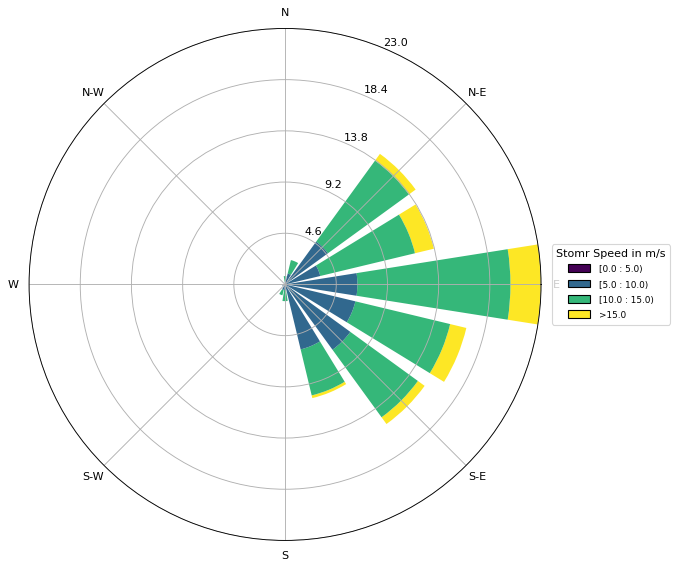

In [17]:
from windrose import WindroseAxes

#Plot Wind Rose
st_dir = np.asarray(storm_mean_direction_vector)+90
st_vel = np.asarray(storm_mean_velocity )
new_labels = ["E", "N-E", "N", "N-W", "W", "S-W", "S", "S-E"]
ax = WindroseAxes.from_ax(theta_labels=new_labels)
ax.bar(st_dir , st_vel, normed=True, bins=np.arange(0, np.max(st_vel), 5))
ax.set_legend(title = 'Stomr Speed in m/s', loc='center right', bbox_to_anchor=(1.25,0.5))

## Wind roses - directions method


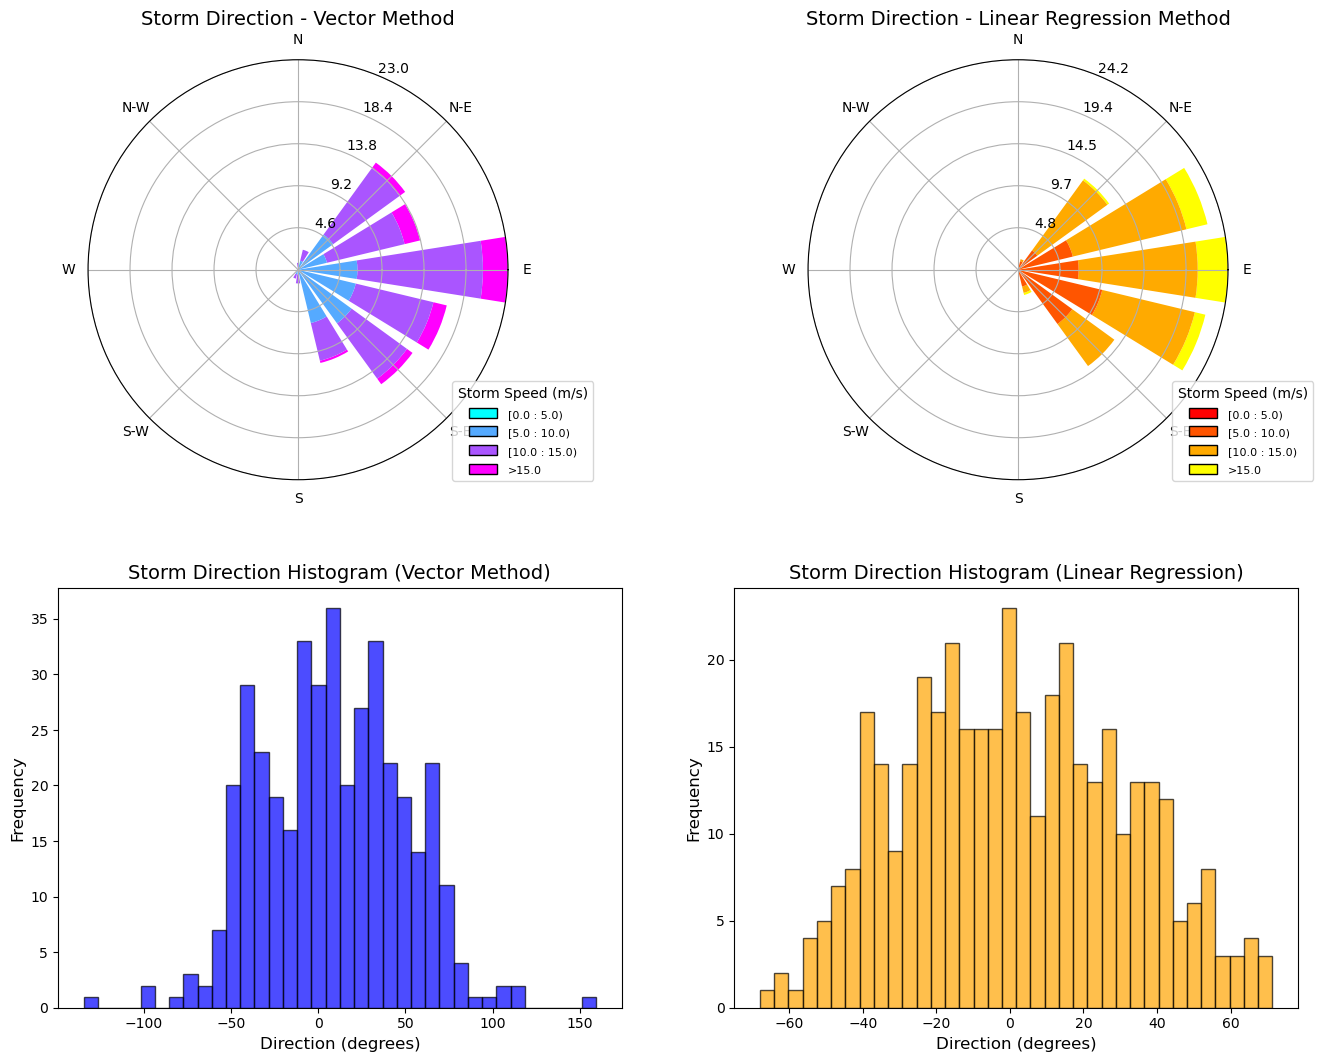

In [18]:
          
# Storm direction for both methods
fig = plt.figure(figsize=(16, 12))

# Define common parameters
new_labels = ["E", "N-E", "N", "N-W", "W", "S-W", "S", "S-E"]
bins = np.arange(0, np.max(storm_mean_velocity), 5)

# Storm direction vector method (Windrose)
ax1 = WindroseAxes.from_ax(fig=fig, rect=[0.1, 0.55, 0.35, 0.35], theta_labels=new_labels)
st_dir_vector = np.asarray(storm_mean_direction_vector) + 90
ax1.bar(st_dir_vector, storm_mean_velocity, normed=True, bins=bins, cmap=plt.get_cmap("cool"))
ax1.set_legend(title='Storm Speed (m/s)', loc='lower right', bbox_to_anchor=(1.2, 0.0))
ax1.set_title('Storm Direction - Vector Method', fontsize=14)

# Storm direction linear regression method (Windrose)
ax2 = WindroseAxes.from_ax(fig=fig, rect=[0.55, 0.55, 0.35, 0.35], theta_labels=new_labels)
st_dir_lm = np.asarray(storm_mean_direction_lm) + 90
ax2.bar(st_dir_lm, storm_mean_velocity, normed=True, bins=bins, cmap=plt.get_cmap("autumn"))
ax2.set_legend(title = 'Storm Speed (m/s)', loc='lower right', bbox_to_anchor=(1.2, 0.0))
ax2.set_title('Storm Direction - Linear Regression Method', fontsize = 14)

# Histogram for storm directions (Vector Method)
ax3 = fig.add_subplot(2, 2, 3)
ax3.hist(storm_mean_direction_vector, bins=36, color='blue', alpha=0.7, edgecolor='black')
ax3.set_title('Storm Direction Histogram (Vector Method)', fontsize = 14)
ax3.set_xlabel('Direction (degrees)', fontsize = 12)
ax3.set_ylabel('Frequency', fontsize = 12)

# Histogram for storm directions (Linear Regression Method)
ax4 = fig.add_subplot(2, 2, 4)
ax4.hist(storm_mean_direction_lm, bins=36, color='orange', alpha=0.7, edgecolor='black')
ax4.set_title('Storm Direction Histogram (Linear Regression)', fontsize = 14)
ax4.set_xlabel('Direction (degrees)', fontsize = 12)
ax4.set_ylabel('Frequency', fontsize = 12)

# Adjust layout for better spacing
#plt.tight_layout()
plt.show()

In [19]:
storm_mean_direction_vector = np.asarray(storm_mean_direction_vector) + 90
storm_mean_direction_lm = np.asarray(storm_mean_direction_lm) + 90 
storm_mean_velocity = np.asarray(storm_mean_velocity) 

Text(0, 0.5, 'Storm Direction (Linear Regression Method)')

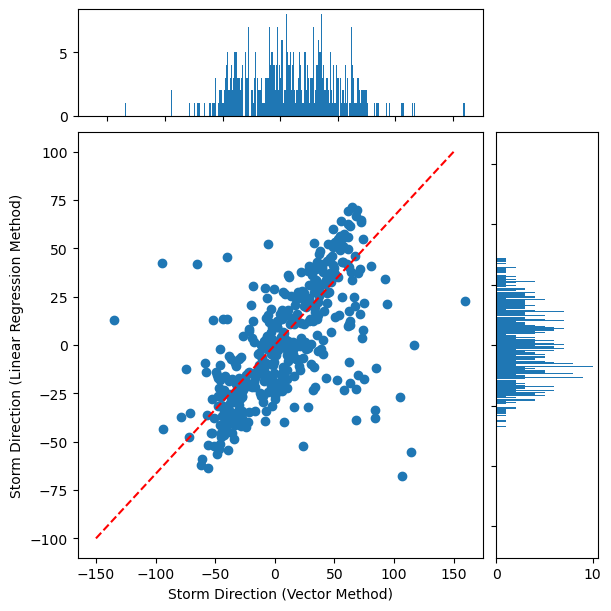

In [56]:
def scatter_hist(x, y, ax, ax_histx, ax_histy):
    # no labels
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)

    # the scatter plot:
    ax.scatter(x, y)
    ax.plot([-150, 150], [-100, 100], 'r--')

    # now determine nice limits by hand:
    binwidth = 1
    xymax = max(np.max(np.abs(x)), np.max(np.abs(y)))
    lim = (int(xymax/binwidth) + 1) * binwidth

    bins = np.arange(-lim, lim + binwidth, binwidth)
    ax_histx.hist(x, bins=bins)
    ax_histy.hist(y, bins=bins, orientation='horizontal')

fig, axs = plt.subplot_mosaic([['histx', '.'],
                               ['scatter', 'histy']],
                              figsize=(6, 6),
                              width_ratios=(4, 1), height_ratios=(1, 4),
                              layout='constrained')
x = storm_mean_direction_vector
y = storm_mean_direction_lm
scatter_hist(x, y, axs['scatter'], axs['histx'], axs['histy'])
axs['scatter'].set_xlabel('Storm Direction (Vector Method)')
axs['scatter'].set_ylabel('Storm Direction (Linear Regression Method)')


## Storm histogram variables


Text(0, 0.5, 'Frequency')

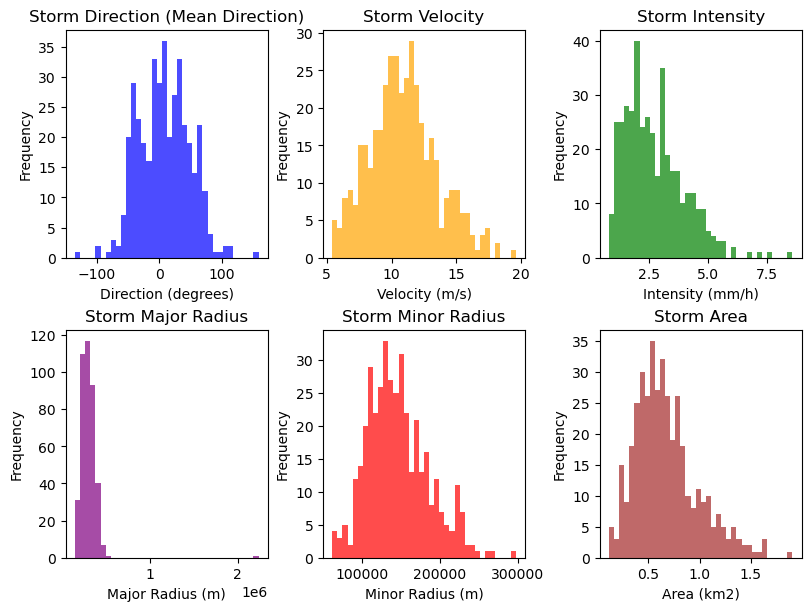

In [57]:
storm_mean_intesity = []
storm_major_radius = []
storm_minus_radius = []
storm_area = []

for storm_event in storm_tracking_results.keys():
    storm = storm_tracking_results[storm_event]
    storm_mean_intesity.append(np.mean(storm['storm_record']['avg_prcp(mm/h)']))
    storm_major_radius.append(np.mean(storm['storm_record']['major_axis_length(m)']))
    storm_minus_radius.append(np.mean(storm['storm_record']['minor_axis_length(m)']))
    storm_area.append(np.mean(storm['selected_storm_area_list']))


fig, axes = plt.subplots(2, 3, figsize=(8, 6), constrained_layout=True)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()
ax1.hist(storm_mean_direction_vector, bins=36, color='blue', alpha=0.7)
ax1.set_title('Storm Direction (Mean Direction)')
ax1.set_xlabel('Direction (degrees)')
ax1.set_ylabel('Frequency')

ax2.hist(storm_mean_velocity, bins=36, color='orange', alpha=0.7)
ax2.set_title('Storm Velocity')
ax2.set_xlabel('Velocity (m/s)')
ax2.set_ylabel('Frequency')

ax3.hist(storm_mean_intesity, bins=36, color='green', alpha=0.7)
ax3.set_title('Storm Intensity')
ax3.set_xlabel('Intensity (mm/h)')
ax3.set_ylabel('Frequency')

ax4.hist(storm_major_radius, bins=36, color='purple', alpha=0.7)
ax4.set_title('Storm Major Radius')
ax4.set_xlabel('Major Radius (m)')
ax4.set_ylabel('Frequency') 

ax5.hist(storm_minus_radius, bins=36, color='red', alpha=0.7)
ax5.set_title('Storm Minor Radius')
ax5.set_xlabel('Minor Radius (m)')
ax5.set_ylabel('Frequency')

ax6.hist(storm_area, bins=36, color='brown', alpha=0.7)
ax6.set_title('Storm Area')
ax6.set_xlabel('Area (km2)')
ax6.set_ylabel('Frequency')


ValueError: Expect x to not have duplicates

/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


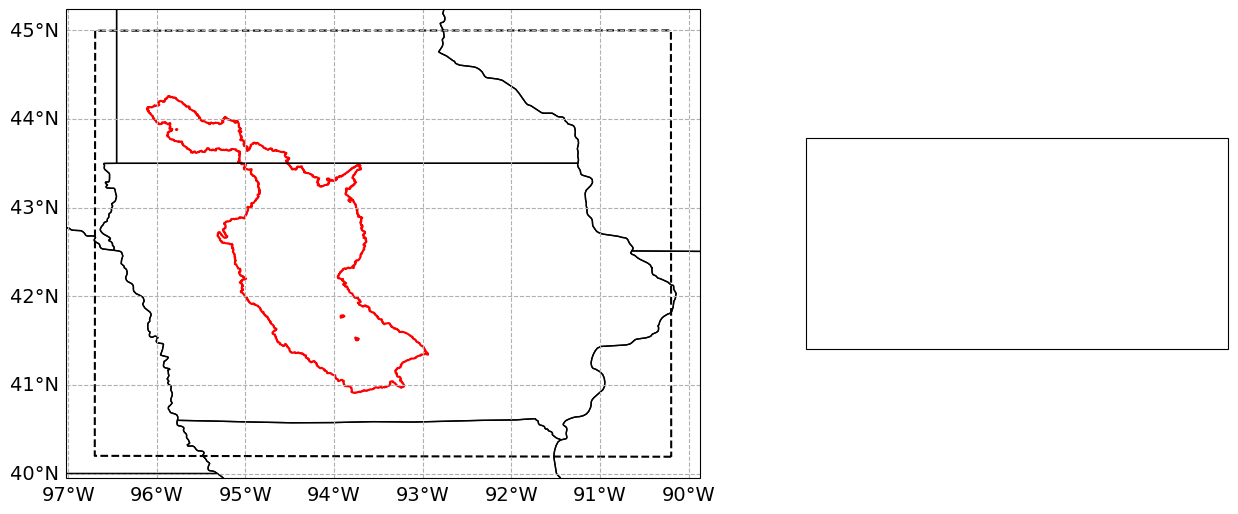

In [58]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
# Define a uniform font size
font_size = 14  # Change this value to adjust text size throughout the figure

# Create a figure with two subplots where the first is 75% and the second is 25%
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 9), gridspec_kw={'width_ratios': [3, 2]},
                         subplot_kw={'projection': ccrs.PlateCarree()})

# Access the two subplots
ax1, ax2 = axes  # Unpack axes for better readability

# Plot basin, transposed basin, and transposition domain
wsh.plot(ax=ax1, facecolor='none', edgecolor='red', linewidth=1.5, label="Original Basin")
#basin_transposed.plot(ax=ax1, facecolor='none', edgecolor='green', linewidth=1.5, label="Transposed Basin")
transposition_domain.plot(ax=ax1, facecolor='none', linestyle='--', edgecolor='black', linewidth=1.5, label="Transposition Domain")

# Add grid with labeled coordinates
gl1 = ax1.gridlines(draw_labels=True, linestyle='--')
gl1.top_labels = False
gl1.right_labels = False
gl1.xlabel_style = {'size': font_size}  # Set font size for x-axis labels
gl1.ylabel_style = {'size': font_size}  # Set font size for y-axis labels

# Add U.S. state boundaries
ax1.add_feature(cfeature.STATES, edgecolor='black', linewidth=1)

for storm_event in storm_tracking_results.keys():
    storm = storm_tracking_results[storm_event]
    x, y = storm['storm_prj_lon_cent_list'], storm['storm_prj_lat_cent_list']
    # Smooth the curve using splines
    x_smooth = np.linspace(x.min(), x.max(), 100)

    # Smooth the curve using splines
    spline = make_interp_spline(x, y, k=3)  # Cubic spline
    y_smooth = spline(x_smooth)
    # Plot the smoothed curve
    plt.plot(x_smooth, y_smooth, 'r-', label='Smoothed Curve')

# **Create a legend using custom handles**
legend_elements = [
    Line2D([0], [0], color='red', lw=2, label="Basin of interest"),
    Line2D([0], [0], color='green', lw=2, label="Area with maximum rainfall"),
    Line2D([0], [0], color='black', lw=2, linestyle='--', label="Transposition Domain"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label="Storm Centroid")
]

# Add the legend to ax1
ax1.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.05, 1.30), fontsize=10)

# Plot rose plot on the second panel
""""
st_dir = np.asarray(storm_mean_direction)+90
st_vel = np.asarray(storm_mean_velocity )
new_labels = ["E", "N-E", "N", "N-W", "W", "S-W", "S", "S-E"]
ax2 = WindroseAxes.from_ax(ax=ax2, theta_labels=new_labels)
ax2.bar(st_dir , st_vel, normed=True, bins=np.arange(0, np.max(st_vel), 5))
ax2.set_legend(title = 'Storm Speed in m/s', loc='center right', bbox_to_anchor=(1.25,0.5))
"""



# Show plot
plt.show()

In [12]:
for storm_event in storm_tracking_results.keys():
    try:
        storm = storm_tracking_results[storm_event]
        x, y = storm['storm_prj_lon_cent_list'], storm['storm_prj_lat_cent_list']
        # Remove duplicate x values
    
        # Smooth the curve using splines
        x_smooth = np.linspace(x.min(), x.max(), 100)
        spline = make_interp_spline(x, y, k=3)  # Cubic spline
        y_smooth = spline(x_smooth)
        # Plot the smoothed curve
        plt.plot(x_smooth, y_smooth, 'r-', label='Smoothed Curve')
    except ValueError as e:
        print(f"Error processing storm event {storm_event}: {e}")

NameError: name 'make_interp_spline' is not defined